Курс "Обработка текстов на естественном языке" 2025 (ЕКЛ) Тема 2.

Сикачев Артем Николаевич 11-301

Упражнение на ститистический анализ тексто с помощью D-TF, IDF

**TF-IDF схема**

TF 

DF

IDF

TF-idf

Работаем с документами на русском языке.

Коллекция из 4 документов:
    oster-m1.txt - Г.Остер. Задачник; oster-m2.txt - Г.Остер. НЕНАГЛЯДНОЕ ПОСОБИЕ ПО МАТЕМАТИКЕ.
    oster-ph1.txt - Г.Остер. Физика. Ненаглядное пособие.
    oster-ph2.txt - Г.Остер. Сборник задач по физике

In [1]:
# Корпус из 4 документов
corpus=["One.txt", "Two.txt", "Three.txt", "Four.txt", "Five.txt", "Six.txt", "Seven.txt", "Eight.txt", "Nine.txt", "Ten.txt"]

In [2]:
N=len(corpus) # Количество документов в корпусе

In [3]:
import re
stopwords_ru = ["а", "в", "с", "и", "у", "на", "*", "как", "это", "этот", "что", "бы", "как", "все", "вы", "но", "он", "не", "я"] # загружаем список стоп-слов для русского языка

In [4]:
# Лемматизация/стемминг для русского языка через NLTK
# Установка: pip install nltk
import nltk
from nltk.stem.snowball import RussianStemmer

stemmer = RussianStemmer()

def lemmatize_word(word):
    """Приводит слово к базовой форме с помощью стеммера NLTK."""
    return stemmer.stem(word)

In [5]:
# аргумент - имя файла с текстом, разделяем на слова, удаляем стоп-слова, лемматизируем, возвращаем список слов
def lexemes(namefile):
    # 1. Разбираем текст из файла на слова:
    file=open(namefile,"r",encoding="utf-8")
    data=file.read()    
    file.close()
    #words=data.split()
    #
    import re
    words=re.split(r'[-\s.,:;!?)()—»«"]+',data)
    # 2. Удаляем стоп-слова, приводим к нижнему регистру:
    listWords = [x.lower() for x in words if x.lower() not in stopwords_ru]
    # 3. Лемматизация — приводим каждое слово к начальной форме
    listWords = [lemmatize_word(w) for w in listWords if w.strip()]
    return listWords

In [6]:
# 1. Создаем двумерный список всех слов, входящих в документы корпуса
#   [[слова документа_0], [слова документа_1], ..., [слова документа_N-1]]
corpusWords=[]
for d in corpus:
    listwords_d=lexemes(d)# список слов документа d
    # добавляем полученный список в общий список
    corpusWords.append(listwords_d)
#print(corpusWords)
print(len(corpusWords)) # число документов
for i in range(len(corpusWords)):
    print(len(corpusWords[i])) # число слов в i-ом документе 

10
74281
4503
3578
1561
63476
1045
49640
56045
48938
2931


In [7]:
# Мешок слов - BoW (bag-of-words)
def compute_bow(list_words):
    # создаем словарь слов и их встречаемости в  документе
    uniqeWordsList=set(list_words)
    dictWords=dict.fromkeys(uniqeWordsList,0)
    for word in list_words:
        dictWords[word] +=1     
    return dictWords

In [8]:
# 2. Создаем мешки слов документов корпуса
listBoWs=[] # список "мешков слов" документов
for i in range(N): # N - количество документов в корпусе
    # цикл по документам корпуса,
    # точнее по спискам слов документов. Эти списки получены на шаге 1.
    bow_i=compute_bow(corpusWords[i])
    listBoWs.append(bow_i)
# Теперь listBoWs[0] - мешок слов документа corpus[0], listBoWs[1] - мешок слов документа corpus[1], ...
#print(listBoWs[3])
#print(listBoWs)
print(listBoWs[0]["мальчик"]) #частота термина t="мальчик" в документе d=corpus[0], т.е. tf_{t,d}=listBoWs[n_d][t], 
                                                                 #  где n_d - номер документа d в corpusWords 

6


Частота термина t в документе d: tf(термин,документ) = количество вождений t в d (Маннинг и др. Инф.поиск, стр.134) Нормализованная Частота термина t в документе d: TF(t,d)= tf(t,d)/число терминов в d (Лейн Х. Обработка текстов...стр.115) Каждый документ имеет свою частоту терминов.

tf_{t,d} = listBoWs[индекс документа d в corpus, t]

In [9]:
# 3. вычисление словаря {слово:tf этого слова} в списке wordDict
def compute_tf(wordDict):
    tfDict = {}
    for word, count in wordDict.items():
        tfDict[word] = count 
    return tfDict

In [10]:
# например
tf_d = compute_tf(listBoWs[0]) # словарь {слово:tf этого слова в документе}
#print(tf_d)
print(tf_d["мальчик"])

6


In [11]:
# 4. вычисление словаря {слово:TF этого слова} в списке wordDict
#    TF(t,d)= tf(t,d)/число терминов в d
def compute_TF(wordDict):
    tfDict = {}
    WordsCount = len(wordDict)
    for word, count in wordDict.items():
        tfDict[word] = count / float(WordsCount)
    return tfDict

In [12]:
# например
TF_d = compute_TF(listBoWs[0]) # словарь {слово:tf этого слова в документе}
#print(TF_d)
print(TF_d["мальчик"])

0.0005772561092938234


Лексикон - все уникальные слова в объединении документов корпуса

In [13]:
# 5. Создание объединенного списка всех слов корпуса документов
# corpusWords - двумерный список слов документов корпуса, созданный на шаге 1
#  создаем список list_all - объединенный список слов всех документов корпуса
list_all=sum(corpusWords,[])
#print(list_all)
print(len(list_all)) # число слов в корпусе документов
print(list_all[33111]) # отдельное слово

305998
рассмея


In [14]:
# 6. 
# Создаем Лексикон - набор уникальных слов в объединении множеств слов корпуса документов

In [15]:
lexicon=sorted(set(list_all))# lexicon упорядочен
#print(lexicon)
print(len(lexicon)) # число уникальных слов в корпусе документов


22041


Inverse Data Frequency (IDF) для слова w = log(количество документов, деленное на количество документов, содержащих слово w). Обратная частота данных определяет вес редких слов во всех документах корпуса.

In [16]:
# 7. Вычисление IDF для всех слов корпуса
# 
def computeIDF(documents):
    import math
    N = len(documents)    
    idfDict = dict.fromkeys(documents[0].keys(), 0) # ???
    for document in documents:
        for word, val in document.items():
            if val > 0:
                idfDict[word] += 1    
    for word, val in idfDict.items():
        idfDict[word] = math.log(N / float(val))
    return idfDict

In [17]:
# 7. Вычисление IDF для всех слов корпуса
def comp_idf(lexicon,corpusWords):
    import math
    N = len(corpusWords)
    idf_lexicon={k:0 for k in lexicon} # 1. начальный словарь - {'слово1':0, 'слово2':0, ... }
    listCorpusSet=[] # 2. список множеств уникальных слов документов корпуса
    for d in corpusWords: # 3. или for i in range(N):
        l_s=set(d) # 4. или l_s=set(corpusWords[i])
        listCorpusSet.append(l_s) # 5.
    for key in idf_lexicon: # for key in lexicon
       # проходим по всем документам корпуса
       # если слово содержится в очередном документе, добавляем 1 в value
        for s in listCorpusSet: # или for i in range(N):
            # если слово key содержится в множестве слов очередного документа
           if key in s: # или if key in set(corpusWords[i]). И можно без операций 2 - 5.
               idf_lexicon[key] += 1
    #
    for word, val in idf_lexicon.items():
        idf_lexicon[word] = math.log(N / float(val))
    return idf_lexicon

In [18]:
IDF_lexicon = comp_idf(lexicon,corpusWords)
#print(IDF_lexicon)

Вычисление TF-IDF = TF x IDF.

In [19]:
def compTFIDF(tf_bow, idfs):
    # 
    tfidf = {}
    for word, val in tf_bow.items():
        tfidf[word] = val * idfs[word]
    return tfidf

In [20]:
# двумерный список, содержащий значения tf-idf слов документов корпуса
# tfidf_corpus[0] - список, содержащий значения tf-idf слов первого документ
tfidf_corpus= [] 
for i in range(N):
    tmp=compTFIDF(listBoWs[i], IDF_lexicon)
    tfidf_corpus.append(tmp)
#print(tfidf_corpus[0]) # список значений tf-idf первого документа
#print(tfidf_corpus[1]) # список значений tf-idf второго документа
#print(tfidf_corpus[2]) # список значений tf-idf третьего документа
#print(tfidf_corpus[3]) # список значений tf-idf четвертого документа

In [21]:
# Создаем список, содержащий словари для каждого документа корпуса
# словарь документа имеет размер, равный размеру lexicon.
# Словарь документа d содержит пары "слово:0", если "слово" отсутствует в документе d 
#                               или "слово:tf-idf('слово',d), если в d есть"слово".
vect_docs=[] # список N словарей, содержащих значения 0 либо значение tf-idf слова 
for m in range(N):
    current={w:0 for w in lexicon}
    for word in lexicon:
        if word in set(corpusWords[m]):
            current[word] = tfidf_corpus[m][word] # или current[word] = listBoWs[m][word]
    vect_docs.append(current)  
#print(vect_docs[0])

In [22]:
# пример определения значений tf-idf для нескольких терминов
terms=["звуч","голос", "непривычн"] # термины
M=len(terms)
for t in terms:
    print("{0}=>{1}".format(t,vect_docs[0][t])) # значения tf-idf для первого документа и терминов из terms
    

звуч=>5.619081861425898
голос=>30.34382850945399
непривычн=>0.5108256237659907


**Визуализация словаря в виде облака слов (word cloud)**

Облако слов строится по словарю частот терминов (например, мешок слов документа). Размер слова пропорционален частоте.

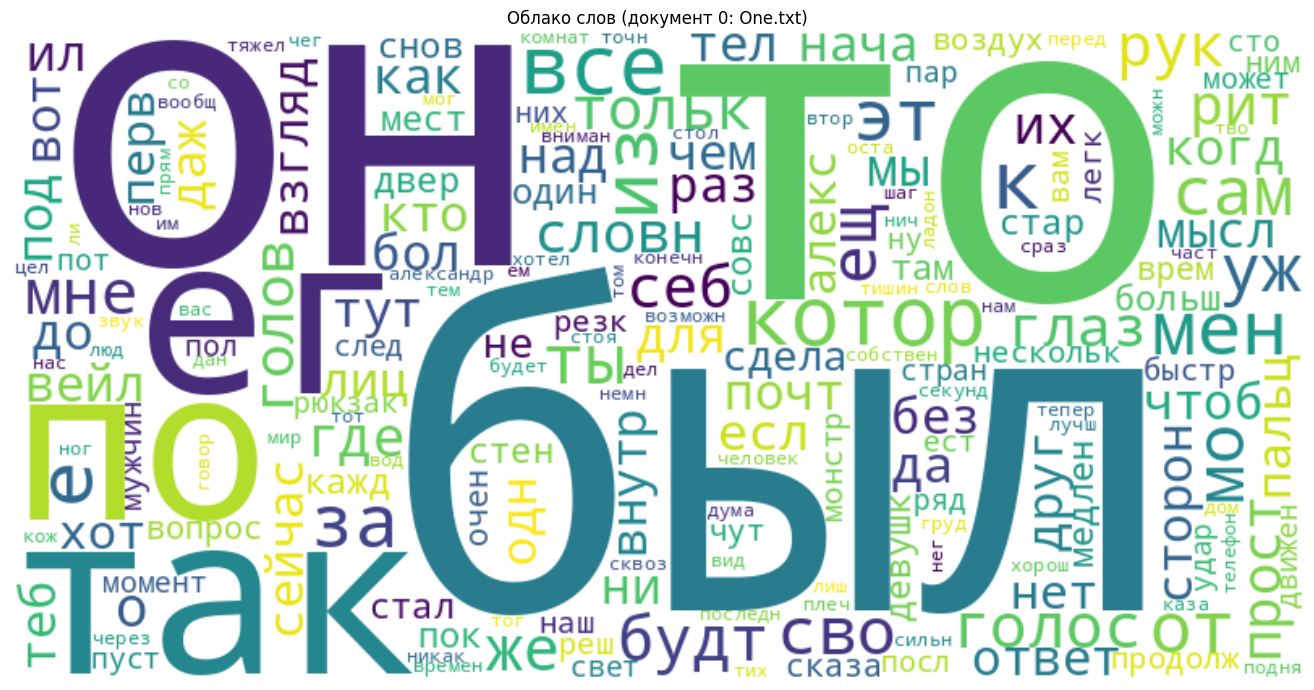

In [23]:
# Облако слов по частотам из словаря
# Установка: pip install wordcloud matplotlib
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(freq_dict, doc_index=0, font_path=None):
    """
    Строит облако слов по словарю частот {слово: количество}.
    freq_dict — мешок слов (listBoWs[i]) или любой dict слово -> частота.
    Для русского текста при проблемах с шрифтом укажите font_path (например, путь к .ttf с кириллицей).
    """
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=200,
        font_path=font_path,
        colormap='viridis'
    ).generate_from_frequencies(freq_dict)
    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Облако слов (документ {doc_index}: {corpus[doc_index]})')
    plt.tight_layout()
    plt.show()

# Пример: облако слов для первого документа по мешку слов
plot_wordcloud(listBoWs[0], doc_index=0)